In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [30]:
from google.colab import files

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier , HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,ConfusionMatrixDisplay, roc_curve)

In [3]:
files.upload()

Saving diabetes.csv to diabetes.csv


{'diabetes.csv': b'Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome\r\n6,148,72,35,169.5,33.6,0.627,50,1\r\n1,85,66,29,102.5,26.6,0.351,31,0\r\n8,183,64,32,169.5,23.3,0.672,32,1\r\n1,89,66,23,94,28.1,0.167,21,0\r\n0,137,40,35,168,43.1,2.288,33,1\r\n5,116,74,27,102.5,25.6,0.201,30,0\r\n3,78,50,32,88,31,0.248,26,1\r\n10,115,70,27,102.5,35.3,0.134,29,0\r\n2,197,70,45,543,30.5,0.158,53,1\r\n8,125,96,32,169.5,34.3,0.232,54,1\r\n4,110,92,27,102.5,37.6,0.191,30,0\r\n10,168,74,32,169.5,38,0.537,34,1\r\n10,139,80,27,102.5,27.1,1.441,57,0\r\n1,189,60,23,846,30.1,0.398,59,1\r\n5,166,72,19,175,25.8,0.587,51,1\r\n7,100,74.5,32,169.5,30,0.484,32,1\r\n0,118,84,47,230,45.8,0.551,31,1\r\n7,107,74,32,169.5,29.6,0.254,31,1\r\n1,103,30,38,83,43.3,0.183,33,0\r\n1,115,70,30,96,34.6,0.529,32,1\r\n3,126,88,41,235,39.3,0.704,27,0\r\n8,99,84,27,102.5,35.4,0.388,50,0\r\n7,196,90,32,169.5,39.8,0.451,41,1\r\n9,119,80,35,169.5,29,0.263,29,1\r\n11,143,94,33,146,36.6,0.

In [4]:
import pandas as pd


df = pd.read_csv("diabetes.csv")

df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


In [5]:
df.columns = df.columns.str.strip().str.lower()
df.columns

df.describe()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
print(df.shape)

df['outcome'].value_counts()

(768, 9)


,count
outcome,
0,500
1,268


In [7]:
df.skew()

# blood pressure , insulin ,age , diabetespedigreefunction

,0
pregnancies,0.901674
glucose,0.532324
bloodpressure,0.140830
skinthickness,0.817477
insulin,3.028046
bmi,0.606416
diabetespedigreefunction,1.919911
age,1.129597
outcome,0.635017


In [49]:
df.duplicated().sum()

np.int64(0)

In [8]:
cols = ['pregnancies','glucose','bloodpressure','skinthickness','insulin','bmi','age']
# df[cols] = df[cols].replace(0 , pd.NA)
for i in cols:
     print(i)
     print((df[i] == 0).sum())

# (768, 9) df shape

pregnancies
111
glucose
0
bloodpressure
0
skinthickness
0
insulin
0
bmi
0
age
0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    float64
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    float64
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [10]:
df.isna().sum()

,0
pregnancies,0
glucose,0
bloodpressure,0
skinthickness,0
insulin,0
bmi,0
diabetespedigreefunction,0
age,0
outcome,0


In [11]:
df.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## EDA - Exploratory Data Analysis

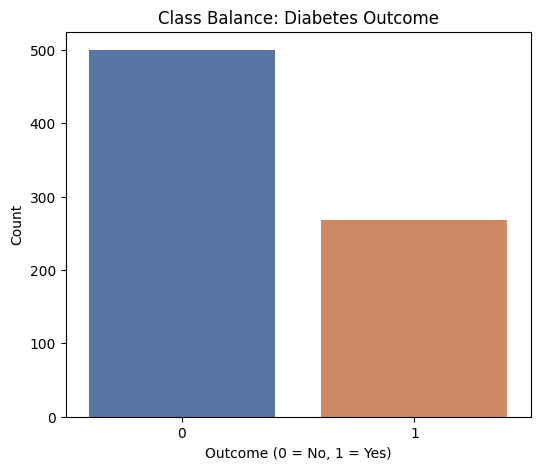

In [17]:
# 1. Target class balance
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='outcome', hue='outcome', palette=['#4C72B0','#DD8452'], legend=False)
plt.title('Class Balance: Diabetes Outcome')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


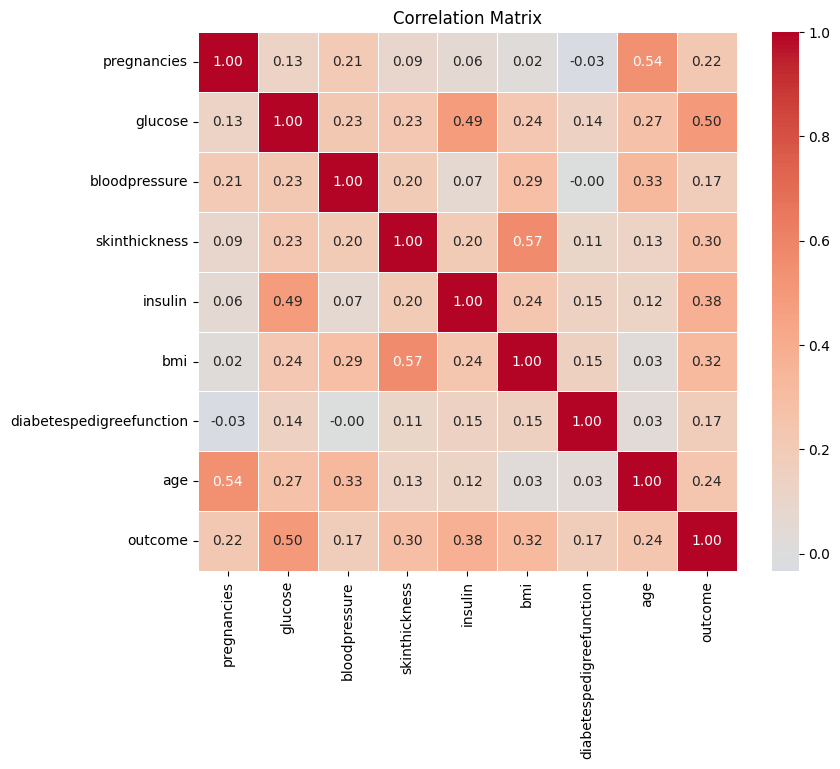

In [18]:
# 2. Correlation heatmap

plt.figure(figsize=(9,7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

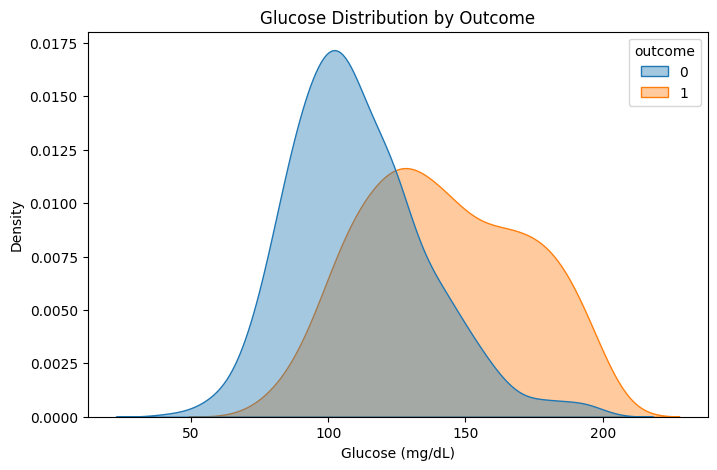

In [20]:
# 3. Glucose distribution by outcome (KDE)

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='glucose', hue='outcome', fill=True, alpha=0.4, common_norm=False)
plt.title('Glucose Distribution by Outcome')
plt.xlabel('Glucose (mg/dL)')
plt.show()

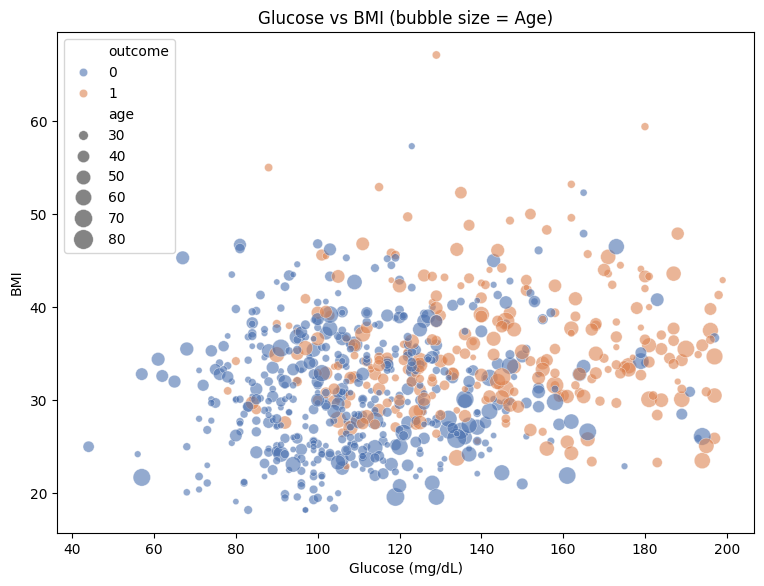

In [24]:
# 4. Glucose vs BMI scatter, bubble size = Age

plt.figure(figsize=(9,6.5))
sns.scatterplot(data=df, x='glucose', y='bmi', hue='outcome', size='age',
                 sizes=(20,200), alpha=0.6, palette=['#4C72B0','#DD8452'])
plt.title('Glucose vs BMI (bubble size = Age)')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('BMI')
plt.show()

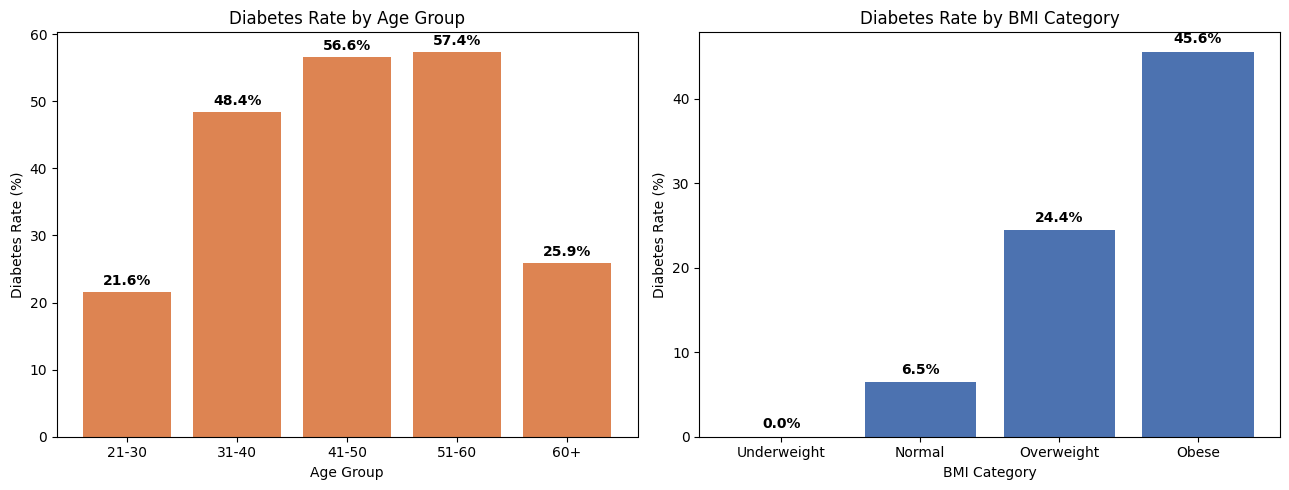

In [26]:
# 5. Diabetes rate by Age Group and BMI Category

df['AgeGroup'] = pd.cut(df['age'], bins=[20,30,40,50,60,100],
                         labels=['21-30','31-40','41-50','51-60','60+'])

df['BMICategory'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100],
                            labels=['Underweight','Normal','Overweight','Obese'])

age_rate = df.groupby('AgeGroup', observed=True)['outcome'].mean() * 100
bmi_rate = df.groupby('BMICategory', observed=True)['outcome'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].bar(age_rate.index.astype(str), age_rate.values, color='#DD8452')
axes[0].set_title('Diabetes Rate by Age Group')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].set_xlabel('Age Group')
for i, v in enumerate(age_rate.values):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(bmi_rate.index.astype(str), bmi_rate.values, color='#4C72B0')
axes[1].set_title('Diabetes Rate by BMI Category')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].set_xlabel('BMI Category')
for i, v in enumerate(bmi_rate.values):
    axes[1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop('outcome', axis=1)
y = df['outcome']


X.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age
0,6,148,72.0,35,169.5,33.6,0.627,50
1,1,85,66.0,29,102.5,26.6,0.351,31
2,8,183,64.0,32,169.5,23.3,0.672,32
3,1,89,66.0,23,94.0,28.1,0.167,21
4,0,137,40.0,35,168.0,43.1,2.288,33


In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, ['pregnancies', 'glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi', 'age'])
    ])


In [27]:
print(df['age'].min(), "-", df['age'].max())

21 - 81


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (614, 8)
Test shape: (154, 8)

Train target distribution:
outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Test target distribution:
outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


In [15]:

pipeline_mlp = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42))
])

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

pipeline_hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=42))
])

counts = y_train.value_counts()
ratio = counts[0] / counts[1]

pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(eval_metric="logloss", random_state=42, scale_pos_weight=ratio))
])

pipeline_catboost = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(
            iterations=200,
            learning_rate=0.05,
            depth=4,
            l2_leaf_reg=5,
            random_seed=42,
            verbose=False
            ))
    ])



In [28]:
models = {
    "MLP": pipeline_mlp,
    "Random Forest": pipeline_rf,
    "HistGradientBoosting": pipeline_hgb,
    "XGBoost": pipeline_xgb,
    "CatBoost": pipeline_catboost,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = {}

for name, pipeline in models.items():
    print(f"Running cross-validation: {name}...")
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}


Running cross-validation: MLP...
Running cross-validation: Random Forest...
Running cross-validation: HistGradientBoosting...
Running cross-validation: XGBoost...
Running cross-validation: CatBoost...


In [29]:
results_df = pd.DataFrame(cv_results).T.sort_values("roc_auc", ascending=False)
results_df.round(4)

,accuracy,precision,recall,f1,roc_auc
HistGradientBoosting,0.8843,0.8540,0.8085,0.8298,0.9471
CatBoost,0.8794,0.8382,0.8131,0.8248,0.9468
XGBoost,0.8794,0.8370,0.8226,0.8275,0.9409
Random Forest,0.8729,0.8378,0.7897,0.8125,0.9339
MLP,0.8338,0.7726,0.7430,0.7566,0.8836


In [38]:

best_model = pipeline_catboost
best_model.fit(X_train, y_train)

y_probs = best_model.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_probs)

for threshold in [0.26, 0.27, 0.29, 0.37, 0.40, 0.47, 0.49]:
    y_pred_thresh = (y_probs >= threshold).astype(int)
    a = accuracy_score(y_train, y_pred_thresh)
    p = precision_score(y_train, y_pred_thresh)
    r = recall_score(y_train, y_pred_thresh)
    f1 = f1_score(y_train, y_pred_thresh)
    print(f"Threshold {threshold}: Accuracy={a:.3f}, Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")

print(f"\nROC-AUC (threshold-independent): {auc:.3f}")

Threshold 0.26: Accuracy=0.923, Precision=0.838, Recall=0.967, F1=0.898
Threshold 0.27: Accuracy=0.925, Precision=0.841, Recall=0.967, F1=0.900
Threshold 0.29: Accuracy=0.935, Precision=0.863, Recall=0.967, F1=0.912
Threshold 0.37: Accuracy=0.941, Precision=0.901, Recall=0.935, F1=0.917
Threshold 0.4: Accuracy=0.948, Precision=0.925, Recall=0.925, F1=0.925
Threshold 0.47: Accuracy=0.953, Precision=0.956, Recall=0.907, F1=0.930
Threshold 0.49: Accuracy=0.953, Precision=0.960, Recall=0.902, F1=0.930

ROC-AUC (threshold-independent): 0.989


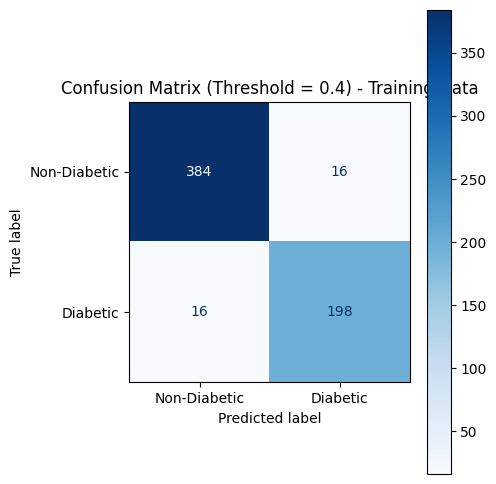

In [40]:
y_train_probs = best_model.predict_proba(X_train)[:, 1]
y_pred_thresh_train = (y_train_probs >= 0.4).astype(int)

cm = confusion_matrix(y_train, y_pred_thresh_train)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix (Threshold = 0.4) - Training Data")
plt.tight_layout()
plt.show()

In [41]:

y_test_probs = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= 0.4).astype(int)
print("Test F1:", f1_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))

Test F1: 0.8256880733944955
Test Precision: 0.8181818181818182
Test Recall: 0.8333333333333334


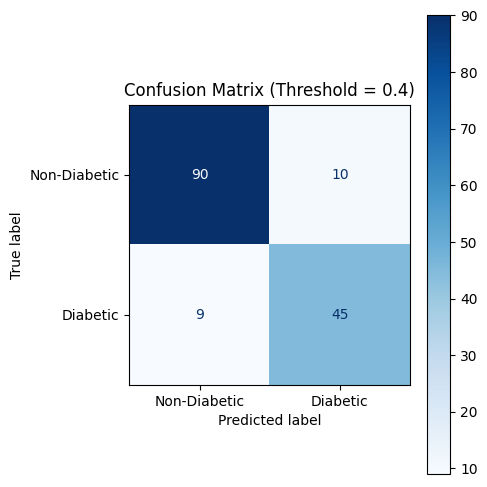

In [42]:
y_probs = best_model.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_probs >= 0.4).astype(int)

cm = confusion_matrix(y_test, y_pred_thresh)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix (Threshold = 0.4)")
plt.tight_layout()
plt.show()

# 90 10
# 12 42 MLP confusion matrix, Catboost is better

In [45]:
from sklearn.base import BaseEstimator, ClassifierMixin

class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, base_pipeline, threshold=0.4):
        self.base_pipeline = base_pipeline
        self.threshold = threshold

    def fit(self, X, y):
        self.base_pipeline.fit(X, y)
        return self

    def predict(self, X):
        probs = self.base_pipeline.predict_proba(X)[:, 1]
        return (probs >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.base_pipeline.predict_proba(X)

best_model_final = ThresholdClassifier(base_pipeline=pipeline_catboost, threshold=0.4)
best_model_final.fit(X_train, y_train)

y_test_probs = best_model_final.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= 0.4).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1:", f1_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_probs))


Test Accuracy: 0.8766233766233766
Test Precision: 0.8181818181818182
Test Recall: 0.8333333333333334
Test F1: 0.8256880733944955
Test ROC-AUC: 0.952962962962963


In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

param_grid = {
    'classifier__depth': [4, 6, 8, 10],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'classifier__iterations': [200, 500, 800],
    'classifier__l2_leaf_reg': [1, 3, 5, 7, 9],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline_catboost,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

# On testing
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


KeyboardInterrupt: 

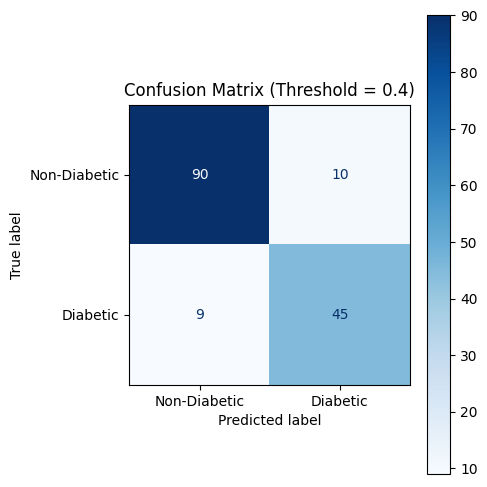

In [47]:

y_pred = best_model_final.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix (Threshold = 0.4)")
plt.tight_layout()
plt.show()

In [46]:
from joblib import dump,load
dump(best_model_final,"best_model_final.joblib")

['best_model_final.joblib']

In [48]:
files.download('best_model_final.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>